In [16]:
"""
Visualisation temps réel de l'AG-TSP — ADEME / CesiCDP
Affichage animé génération par génération dans une fenêtre matplotlib.

Lancer avec :  python tsp_visualisation.py
"""

import random
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import csv
import os
from pathlib import Path
from split_dataset import chunk_file_by_rows, collect_solomon_dataset

## Section 1 — Modèle : villes et matrice de distances

La classe `Ville` représente un nœud du graphe avec ses coordonnées `(x, y)`, une **fenêtre temporelle** `[a_i, b_i]` (en minutes depuis le départ du dépôt) et un **temps de service** `s_i`.

La distance entre deux villes est calculée par la **distance euclidienne** :

$$d(a, b) = \sqrt{(x_a - x_b)^2 + (y_a - y_b)^2}$$

La matrice `c_base` stocke les coûts nominaux. Le coût dynamique $c_{ij}(t)$ est calculé à la volée en tenant compte des perturbations actives à l'instant $t$ (section 2).

In [17]:

class Ville:
    def __init__(self, nom: str, x: float, y: float,
                 fenetre: tuple = (0, float('inf')),
                 service: float = 0.0):
        self.nom     = nom
        self.x       = x
        self.y       = y
        self.a       = fenetre[0]   # heure d'ouverture
        self.b       = fenetre[1]   # heure de fermeture (deadline)
        self.service = service      # temps de service s_i (minutes)

    def __repr__(self):
        return self.nom


def duree_trajet_base(a: 'Ville', b: 'Ville') -> float:
    """Coût nominal (distance euclidienne entre deux villes)."""
    return math.sqrt((a.x - b.x) ** 2 + (a.y - b.y) ** 2)


def cout_dynamique(i: int, j: int, t: float,
                   matrice_base: list,
                   perturbations: list) -> float:
    """
    Coût de transit de la ville i vers la ville j en partant au temps t.

    c_ij(t) = c_base[i][j] * (1 + delta_ij(t))

    Paramètres
    ----------
    i, j          : indices des villes
    t             : instant de départ de la ville i
    matrice_base  : matrice des coûts nominaux (liste de listes)
    perturbations : liste de dicts
                    { 'arc': (i,j), 't_debut': float, 't_fin': float, 'alpha': float }
                    L'arc est symétrique : (i,j) == (j,i)
    """
    base = matrice_base[i][j]
    for p in perturbations:
        arc = p['arc']
        if (arc == (i, j) or arc == (j, i)) and p['t_debut'] <= t <= p['t_fin']:
            return base * p['alpha']
    return base


def construire_matrice(villes: list) -> list:
    """Matrice des coûts nominaux (statiques)."""
    n = len(villes)
    return [[duree_trajet_base(villes[i], villes[j]) for j in range(n)] for i in range(n)]


# ── Helpers de chargement (inchangés) ───────────────────────────────────────

def charger_villes_csv_tsp(chemin_csv, chunk_size) -> list:
    """Parser pour tsp_dataset.csv dont les coords sont stockées comme [[x,y],[x,y],...] """
    import ast
    csv.field_size_limit(10_000_000)
    villes = []
    with open(chemin_csv, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            coords_str = row.get('city_coordinates')
            if not coords_str:
                continue
            try:
                coords = ast.literal_eval(coords_str)
                for point in coords:
                    idx = len(villes)
                    # Fenêtre par défaut large + service nul (TSP classique si non fourni)
                    villes.append(Ville(f"Ville {idx}", float(point[0]), float(point[1])))
                    if len(villes) >= chunk_size:
                        return villes
            except Exception:
                continue
    return villes


def charger_villes_depuis_split(chunk_size: int = 20, source: str = "solomon") -> list:
    raw_dir = Path("./dataset_raw")

    if source == "solomon":
        groupes = collect_solomon_dataset(raw_dir)
        tous_les_fichiers = []
        for fichiers in groupes.values():
            tous_les_fichiers.extend(fichiers)
        if not tous_les_fichiers:
            raise FileNotFoundError("Aucun fichier Solomon trouvé dans dataset_raw")
        villes = []
        for chemin_csv in tous_les_fichiers:
            with open(chemin_csv, newline='', encoding='utf-8') as f:
                reader = csv.reader(f)
                next(reader)
                for row in reader:
                    if len(row) < 3:
                        continue
                    idx = len(villes)
                    villes.append(Ville(f"Ville {idx}", float(row[1]), float(row[2])))
                    if len(villes) >= chunk_size:
                        return villes
        return villes

    elif source == "tsp":
        tsp_src = raw_dir / "chunks" / "tsp_dataset" / "tsp_dataset.csv"
        if not tsp_src.exists():
            raise FileNotFoundError(f"Fichier TSP introuvable : {tsp_src.resolve()}")
        return charger_villes_csv_tsp(tsp_src, chunk_size)

    raise ValueError(f"Source inconnue : '{source}'. Valeurs acceptées : 'solomon', 'tsp'")


def charger_villes_csv(chemin_csv):
    villes = []
    with open(chemin_csv, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 3:
                continue
            nom = f"Ville {row[0]}"
            x = float(row[1])
            y = float(row[2])
            villes.append(Ville(nom, x, y))
    return villes


def charger_villes_depuis_dossiers(nb_fichiers):
    base_path = r"dataset_split\split_60_20_20\test\solomon_dataset"
    villes = []
    fichiers_pris = 0
    for dossier in sorted(os.listdir(base_path)):
        dossier_path = os.path.join(base_path, dossier)
        if os.path.isdir(dossier_path):
            for fichier in sorted(os.listdir(dossier_path)):
                if fichier.endswith(".csv"):
                    chemin_csv = os.path.join(dossier_path, fichier)
                    villes += charger_villes_csv(chemin_csv)
                    fichiers_pris += 1
                    if fichiers_pris >= nb_fichiers:
                        return villes
    return villes


## Section 2 — Opérateurs génétiques (TSPTW-D)

C'est le cœur de l'algorithme. Chaque individu est un **chromosome** : une permutation des indices de villes (hors dépôt).

### Fitness TSPTW-D — contrainte souple sur les fenêtres

La simulation propage l'horloge étape par étape :

$$\tau_{\sigma_{k+1}} = \max(\tau_{\sigma_k},\ a_{\sigma_k}) + s_{\sigma_k} + c_{\sigma_k,\sigma_{k+1}}(d_{\sigma_k})$$

**Arrivée avant ouverture** (`t < aᵢ`) : le véhicule **attend** — l'horloge avance jusqu'à `aᵢ`. Pas de pénalité (comportement normal TSPTW).

**Arrivée après fermeture** (`t > bᵢ`) : la ville est fermée mais **la tournée continue**. On applique une **pénalité proportionnelle au dépassement** :

$$\text{pénalité}_i = \lambda \cdot (\tau_i - b_i)$$

où $\lambda$ (`penalite_par_retard`) est un grand coefficient qui pénalise fortement le dépassement sans l'interdire. La livraison s'effectue quand même à `t` (pas d'attente de réouverture dans l'ordre du chromosome — l'AG est libre de réordonner les visites pour éviter ces situations).

La fitness totale est donc :

$$F(\sigma) = \tau_0^{\text{retour}} + \lambda \sum_{k=1}^{n} \max(0,\ \tau_{\sigma_k} - b_{\sigma_k})$$

Plus $F$ est faible, meilleure est la tournée. L'AG va naturellement apprendre à **éviter les dépassements** car ils coûtent très cher.

### Coûts dynamiques

Le transit entre deux villes utilise `cout_dynamique(i, j, t, ...)` qui applique le facteur $\alpha$ si l'arc est perturbé à l'instant $t$.

### Sélection, croisement OX et mutation 2-opt

Inchangés — ils opèrent sur les permutations.


In [18]:

def fitness(chromosome: list,
            villes: list,
            matrice_base: list,
            perturbations: list,
            penalite_par_retard: float = 1e4) -> float:
    """
    Évalue la qualité d'une tournée pour le TSPTW-D.

    Contrainte 1 — Fenêtres temporelles (souple) :
      - Arrivée avant ouverture (t < a_i) : le véhicule attend → horloge avance à a_i
      - Arrivée après fermeture (t > b_i) : pénalité proportionnelle au dépassement,
        la tournée continue normalement (on ne bloque pas ni on ne rejette).
        L'AG apprend ainsi à réordonner les visites pour éviter ces dépassements.

    Contrainte 2 — Coûts dynamiques :
      - Le coût de transit c_ij(t) est calculé à l'instant de départ de la ville i,
        en tenant compte des perturbations actives.

    Paramètres
    ----------
    chromosome          : permutation des indices clients (sans le dépôt 0)
    villes              : liste de Ville (index 0 = dépôt)
    matrice_base        : matrice des coûts nominaux
    perturbations       : liste de perturbations { 'arc', 't_debut', 't_fin', 'alpha' }
    penalite_par_retard : facteur λ multiplié par chaque unité de dépassement de b_i

    Retourne
    --------
    F(σ) = durée_totale + λ * Σ max(0, τ_i - b_i)
    Une valeur faible = tournée rapide et respectueuse des fenêtres.
    """
    tournee   = [0] + chromosome + [0]
    t         = 0.0    # horloge courante (départ du dépôt à t=0)
    penalite  = 0.0    # pénalité accumulée pour les dépassements de fenêtres

    for k in range(len(tournee) - 1):
        i = tournee[k]
        j = tournee[k + 1]

        ville_i = villes[i]

        # ── Contrainte 1 : gestion de la fenêtre temporelle ─────────────
        if t > ville_i.b:
            # Arrivée après fermeture → pénalité proportionnelle au dépassement
            # La livraison s'effectue quand même (contrainte souple)
            penalite += penalite_par_retard * (t - ville_i.b)
            # Pas d'attente supplémentaire : on livre immédiatement à t
            t += ville_i.service
        else:
            # Arrivée avant fermeture :
            #   - si avant ouverture → attente jusqu'à a_i (normal TSPTW)
            #   - si dans la fenêtre → livraison immédiate
            t = max(t, ville_i.a) + ville_i.service

        # ── Contrainte 2 : coût dynamique en fonction du temps t ────────
        c = cout_dynamique(i, j, t, matrice_base, perturbations)
        t += c

    return t + penalite


def creer_chromosome(n_villes: int) -> list:
    genes = list(range(1, n_villes))
    random.shuffle(genes)
    return genes


def initialiser_population(taille: int, n_villes: int) -> list:
    return [creer_chromosome(n_villes) for _ in range(taille)]


def selection_tournoi(population: list, villes: list, matrice_base: list,
                      perturbations: list, k: int = 3) -> list:
    """Sélection par tournoi — utilise la fitness TSPTW-D."""    
    candidats = random.sample(population, k)
    return min(candidats,
               key=lambda c: fitness(c, villes, matrice_base, perturbations))


def ox_crossover(p1: list, p2: list) -> list:
    """Croisement OX — produit une permutation valide."""    
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    enfant = [-1] * n
    enfant[a:b + 1] = p1[a:b + 1]
    segment = set(p1[a:b + 1])
    reste = [g for g in p2 if g not in segment]
    pos = 0
    for i in range(n):
        if enfant[i] == -1:
            enfant[i] = reste[pos]
            pos += 1
    return enfant


def mutation_2opt(chromosome: list, taux: float) -> list:
    """Mutation 2-opt — inverse un sous-segment aléatoire."""    
    chrom = chromosome[:]
    if random.random() < taux:
        i, j = sorted(random.sample(range(len(chrom)), 2))
        chrom[i:j + 1] = reversed(chrom[i:j + 1])
    return chrom



## Section 3 — Initialisation de la fenêtre

Purement graphique (matplotlib). La figure est créée **une seule fois** pour éviter de recréer les objets à chaque génération. Seules les *données* des artistes (coordonnées de la route, séries temporelles) sont mises à jour — technique classique d'animation différentielle.

In [19]:

def _init_figure(villes: list):
    """
    Crée la figure matplotlib avec 3 panneaux.
    Les éléments statiques (points des villes, axes) sont dessinés une fois.
    Retourne (fig, artistes) où artistes est un dict des objets à mettre à jour.
    """
    plt.ion()
    fig = plt.figure(figsize=(14, 6), facecolor="#f8f8f6")
    fig.suptitle(
        "Algorithme Génétique — Optimisation de tournées  |  ADEME / CesiCDP",
        fontsize=12, fontweight="bold", color="#2c2c2a", y=0.99,
    )

    gs = gridspec.GridSpec(
        2, 2, figure=fig,
        left=0.06, right=0.97, top=0.93, bottom=0.13,  # bottom plus grand = place pour le texte
        wspace=0.45, hspace=0.50,
    )
    ax_carte  = fig.add_subplot(gs[:, 0])  # toute la colonne gauche
    ax_conv   = fig.add_subplot(gs[0, 1])  # convergence
    ax_divers = fig.add_subplot(gs[1, 1])  # diversité

    # ── Panneau carte : éléments fixes ───────────────────────
    xs = np.array([v.x for v in villes])
    ys = np.array([v.y for v in villes])
    marge = 1

    ax_carte.set_facecolor("#eef3ee")
    ax_carte.set_xlabel("km (est-ouest)", fontsize=9, color="#5f5e5a")
    ax_carte.set_ylabel("km (nord-sud)",  fontsize=9, color="#5f5e5a")
    ax_carte.tick_params(labelsize=8, colors="#5f5e5a")
    ax_carte.set_xlim(xs.min() - marge, xs.max() + marge)
    ax_carte.set_ylim(ys.min() - marge, ys.max() + marge)

    # Points des villes (dessinés une seule fois, ne bougent pas)
    ax_carte.scatter(xs[1:], ys[1:], s=60,  color="#534AB7",
                     zorder=4, edgecolors="white", linewidths=0.8)
    ax_carte.scatter(xs[0],  ys[0],  s=180, color="#BA7517",
                     zorder=5, marker="*", edgecolors="white", linewidths=0.8)

    # Artiste de la route : seules ses données changent à chaque génération
    (ligne_route,) = ax_carte.plot([], [], "-", color="#1D9E75",
                                   linewidth=2, alpha=0.8, zorder=3)

    txt_info = fig.text(
        0.02, 0.01, "",          # x=0.02 (bord gauche), y=0.01 (tout en bas)
        fontsize=9, color="#2c2c2a",
        verticalalignment="bottom", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                alpha=0.85, edgecolor="#d3d1c7"),
    )
    titre_carte = ax_carte.set_title(
        "Génération 0", fontsize=11, color="#2c2c2a", pad=5
    )
    ax_carte.legend(
        handles=[
            Line2D([0],[0], marker="*", color="w",
                   markerfacecolor="#BA7517", markersize=12, label="Dépôt"),
            Line2D([0],[0], marker="o", color="w",
                   markerfacecolor="#534AB7", markersize=7,  label="Livraison"),
            Line2D([0],[0], color="#1D9E75", lw=2, label="Meilleure tournée"),
        ],
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),      # x=1.01 = juste à droite du panneau
        borderaxespad=0,
        framealpha=0.85,
        edgecolor="#d3d1c7",
        )

    # ── Panneau convergence : artistes réutilisables ──────────
    ax_conv.set_facecolor("#f8f8f6")
    ax_conv.set_title("Convergence", fontsize=10, color="#2c2c2a", pad=4)
    ax_conv.set_xlabel("Génération", fontsize=8.5, color="#5f5e5a")
    ax_conv.set_ylabel("Distance (km)", fontsize=8.5, color="#5f5e5a")
    ax_conv.tick_params(labelsize=8, colors="#5f5e5a")

    (line_best,)  = ax_conv.plot([], [], color="#0F6E56", lw=2,   label="Meilleure")
    (line_mean,)  = ax_conv.plot([], [], color="#185FA5", lw=1.2, label="Moyenne", alpha=0.75)
    (line_worst,) = ax_conv.plot([], [], color="#993C1D", lw=0.8, label="Pire",
                                  linestyle="--", alpha=0.5)
    fill_ref = [ax_conv.fill_between([], [], [], alpha=0.08, color="#185FA5")]
    ax_conv.legend(fontsize=8, loc="upper right",
                   framealpha=0.85, edgecolor="#d3d1c7")

    # ── Panneau diversité : reconstruit à chaque rafraîchissement
    ax_divers.set_facecolor("#f8f8f6")
    ax_divers.set_title("Diversité population", fontsize=10, color="#2c2c2a", pad=4)
    ax_divers.set_ylabel("Distance (km)", fontsize=8.5, color="#5f5e5a")
    ax_divers.tick_params(labelsize=8, colors="#5f5e5a")
    ax_divers.set_xticks([])

    artistes = dict(
        ax_carte   = ax_carte,
        ax_conv    = ax_conv,
        ax_divers  = ax_divers,
        ligne_route= ligne_route,
        txt_info   = txt_info,
        titre_carte= titre_carte,
        line_best  = line_best,
        line_mean  = line_mean,
        line_worst = line_worst,
        fill_ref   = fill_ref,   # liste mutable pour pouvoir remplacer le patch
    )
    return fig, artistes


## Section 4 — Mise à jour de l'affichage

À chaque rafraîchissement, trois panneaux sont mis à jour :

- **Carte** — tournée courante
- **Courbe de convergence** — meilleur / moyen / pire
- **Boxplot de diversité** — dispersion des fitness

La diversité de population est estimée par l'écart-type des valeurs de fitness :

$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\bigl(f(\pi_i) - \bar{f}\bigr)^2}$$


In [20]:

def _maj_affichage(
    fig, artistes, villes,
    generation: int,
    meilleur: list,
    meilleure_dur: float,
    initiale_dur: float,
    hist_best: list,
    hist_mean: list,
    hist_worst: list,
    population: list,
    matrice_base: list,
    perturbations: list,
):
    ax_conv   = artistes["ax_conv"]
    ax_divers = artistes["ax_divers"]

    # ── Carte ─────────────────────────────────────────────────
    tournee = [0] + meilleur + [0]
    artistes["ligne_route"].set_data(
        [villes[i].x for i in tournee],
        [villes[i].y for i in tournee],
    )
    gain = (initiale_dur - meilleure_dur) / initiale_dur * 100 if initiale_dur > 0 else 0
    artistes["txt_info"].set_text(
        f"Score : {meilleure_dur:.1f}\nGain  : -{gain:.1f}%"
    )
    artistes["titre_carte"].set_text(
        f"Meilleure tournée — génération {generation}"
    )

    # ── Convergence ───────────────────────────────────────────
    gens = np.arange(len(hist_best))
    artistes["line_best"].set_data(gens, hist_best)
    artistes["line_mean"].set_data(gens, hist_mean)
    artistes["line_worst"].set_data(gens, hist_worst)

    artistes["fill_ref"][0].remove()
    artistes["fill_ref"][0] = ax_conv.fill_between(
        gens, hist_worst, hist_best, alpha=0.08, color="#185FA5"
    )
    ax_conv.set_xlim(0, max(len(hist_best) + 1, 10))
    ax_conv.set_ylim(min(hist_best) * 0.97, max(hist_worst) * 1.03)

    # ── Diversité (boxplot + strip) ───────────────────────────
    ax_divers.cla()
    ax_divers.set_facecolor("#f8f8f6")
    ax_divers.set_title("Diversité population", fontsize=10, color="#2c2c2a", pad=4)
    ax_divers.set_ylabel("Score fitness", fontsize=8.5, color="#5f5e5a")
    ax_divers.tick_params(labelsize=8, colors="#5f5e5a")
    ax_divers.set_xticks([])

    scores = np.array([
        fitness(c, villes, matrice_base, perturbations)
        for c in population
    ])

    ax_divers.boxplot(
        scores, vert=True, patch_artist=True, widths=0.45,
        boxprops    =dict(facecolor="#B5D4F4", color="#185FA5", linewidth=1.2),
        medianprops =dict(color="#0F6E56",     linewidth=2),
        whiskerprops=dict(color="#185FA5",     linewidth=1),
        capprops    =dict(color="#185FA5",     linewidth=1.2),
        flierprops  =dict(marker="o", color="#993C1D", markersize=3, alpha=0.45),
    )
    jitter = np.random.uniform(-0.18, 0.18, len(scores))
    ax_divers.scatter(1 + jitter, scores, alpha=0.2, s=8, color="#534AB7", zorder=2)
    ax_divers.text(
        0.97, 0.97,
        f"min  {scores.min():.0f}\nmoy  {scores.mean():.0f}\n"
        f"max  {scores.max():.0f}\nσ    {scores.std():.0f}",
        transform=ax_divers.transAxes, fontsize=8,
        color="#2c2c2a", va="top", ha="right", family="monospace",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  alpha=0.85, edgecolor="#d3d1c7"),
    )

    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.pause(0.05)



## Section 5 — Boucle principale (TSPTW-D)

C'est la boucle de l'**algorithme génétique** adapté au TSPTW-D. À chaque génération $t$ :

1. Tri de la population par fitness croissante (les tournées infaisables sont reléguées en fin de classement)
2. Conservation des $n_e = \lfloor \alpha \cdot N \rfloor$ meilleurs **(élitisme)**
3. Génération de $N - n_e$ enfants par sélection + croisement + mutation
4. Mise à jour du meilleur global

Les perturbations sont passées à toutes les évaluations de fitness, ce qui force l'AG à trouver des tournées **qui contournent les arcs perturbés ou les empruntent hors de la plage de perturbation**.

### Critère d'arrêt anticipé

Si $f_{\text{best}}$ ne s'améliore pas pendant $p$ générations consécutives (`patience`), l'algorithme s'arrête.


In [21]:

def lancer_visualisation(
    villes: list,
    perturbations: list     = None,
    taille_pop: int         = 80,
    n_generations: int      = 300,
    taux_croisement: float  = 0.85,
    taux_mutation: float    = 0.12,
    taux_elitisme: float    = 0.10,
    patience: int           = 80,
    penalite_par_retard: float = 1e4,
) -> tuple:
    """
    Lance l'AG TSPTW-D et affiche son évolution génération par génération.

    Paramètres
    ----------
    villes              : liste de Ville (index 0 = dépôt).
                          Chaque Ville peut porter une fenêtre [a, b] et un temps de service.
    perturbations       : liste de dicts décrivant les perturbations dynamiques, ex :
                          [{'arc': (2, 3), 't_debut': 80, 't_fin': 160, 'alpha': 2.5}]
                          Laisser None ou [] pour un TSP classique sans perturbation.
    taille_pop          : nombre d'individus dans la population
    n_generations       : nombre maximum de générations
    taux_croisement     : probabilité de croisement OX
    taux_mutation       : probabilité de mutation 2-opt
    taux_elitisme       : fraction des meilleurs conservés sans modification
    patience            : arrêt si aucune amélioration pendant N générations
    penalite_par_retard : facteur λ appliqué sur chaque unité de dépassement de b_i

    Retourne
    --------
    (meilleur_chromosome, meilleur_score, historique_best)
    """
    if perturbations is None:
        perturbations = []

    if len(villes) < 3:
        print("Erreur : Il faut au moins 3 villes pour lancer l'algorithme génétique.")
        return None, 0, []

    n_villes     = len(villes)
    matrice_base = construire_matrice(villes)
    n_elite      = max(1, int(taille_pop * taux_elitisme))

    def _fit(c):
        return fitness(c, villes, matrice_base, perturbations, penalite_par_retard)

    population    = initialiser_population(taille_pop, n_villes)
    meilleur      = min(population, key=_fit)
    meilleure_dur = _fit(meilleur)
    initiale_dur  = meilleure_dur

    scores_init   = [_fit(c) for c in population]
    hist_best     = [meilleure_dur]
    hist_mean     = [float(np.mean(scores_init))]
    hist_worst    = [float(np.max(scores_init))]
    sans_amelioration = 0

    fig, artistes = _init_figure(villes)

    debut = time.time()

    for gen in range(1, n_generations + 1):

        population.sort(key=_fit)
        nouvelle_pop = population[:n_elite]

        while len(nouvelle_pop) < taille_pop:
            p1     = selection_tournoi(population, villes, matrice_base,
                                       perturbations)
            p2     = selection_tournoi(population, villes, matrice_base,
                                       perturbations)
            enfant = ox_crossover(p1, p2) if random.random() < taux_croisement else p1[:]
            enfant = mutation_2opt(enfant, taux_mutation)
            nouvelle_pop.append(enfant)

        population   = nouvelle_pop
        dur_candidat = _fit(population[0])

        if dur_candidat < meilleure_dur:
            meilleure_dur     = dur_candidat
            meilleur          = population[0][:]
            sans_amelioration = 0
        else:
            sans_amelioration += 1

        scores_gen = [_fit(c) for c in population]
        hist_best.append(meilleure_dur)
        hist_mean.append(float(np.mean(scores_gen)))
        hist_worst.append(float(np.max(scores_gen)))

        if sans_amelioration >= patience:
            print(f"  Arrêt anticipé — génération {gen} "
                  f"(stagnation sur {patience} gén.)")
            break

    _maj_affichage(fig, artistes, villes, gen,
                   meilleur, meilleure_dur, initiale_dur,
                   hist_best, hist_mean, hist_worst,
                   population, matrice_base, perturbations)

    duree_calcul = time.time() - debut
    gain_final   = (initiale_dur - meilleure_dur) / initiale_dur * 100 if initiale_dur > 0 else 0
    print(f"\n  Terminé en {duree_calcul:.2f}s  |  "
          f"score initial {initiale_dur:.0f} → {meilleure_dur:.0f}  |  "
          f"Gain : -{gain_final:.1f}%")

    plt.ioff()
    plt.show()
    return meilleur, meilleure_dur, hist_best


Villes chargées : 10
  Arrêt anticipé — génération 368 (stagnation sur 350 gén.)


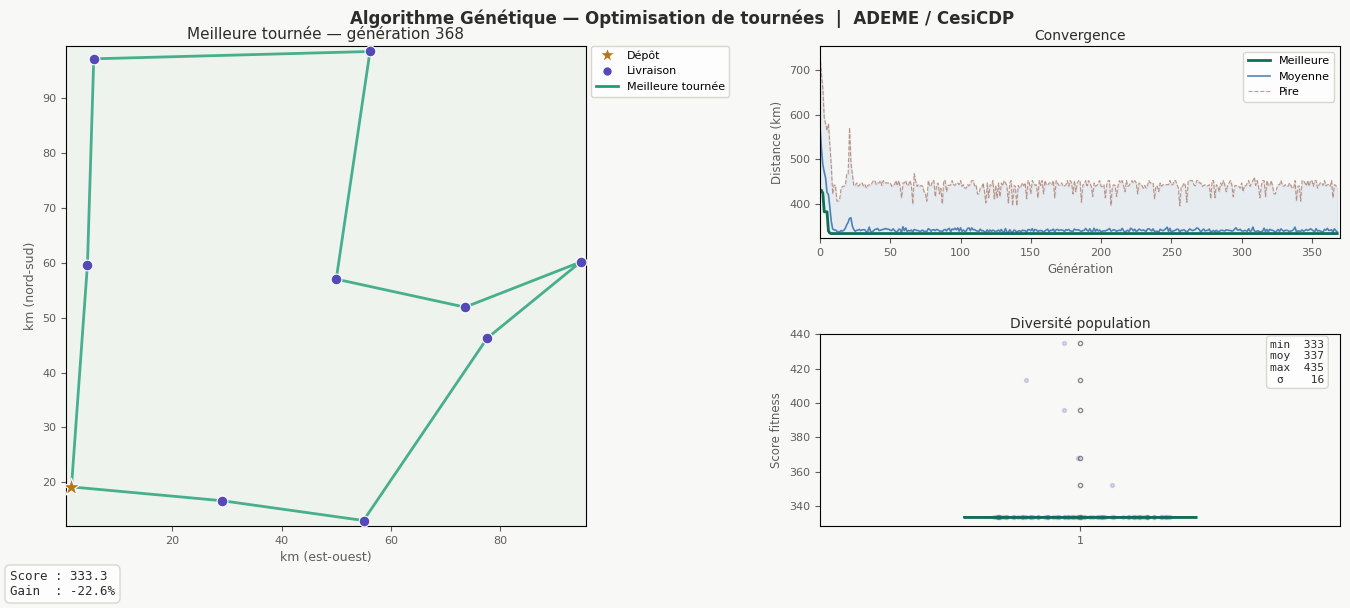


  Terminé en 0.99s  |  score initial 431 → 333  |  Gain : -22.6%


In [22]:
# ── Exemple 1 : TSP pur (pas de fenêtres, pas de perturbations) ──────────────
villes = charger_villes_depuis_split(chunk_size=10, source="tsp")
print(f"Villes chargées : {len(villes)}")
lancer_visualisation(
    villes,
    perturbations   = [],          # aucune perturbation → comportement TSP classique
    taille_pop      = 80,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 350,
);


Villes chargées : 20
  Arrêt anticipé — génération 403 (stagnation sur 350 gén.)


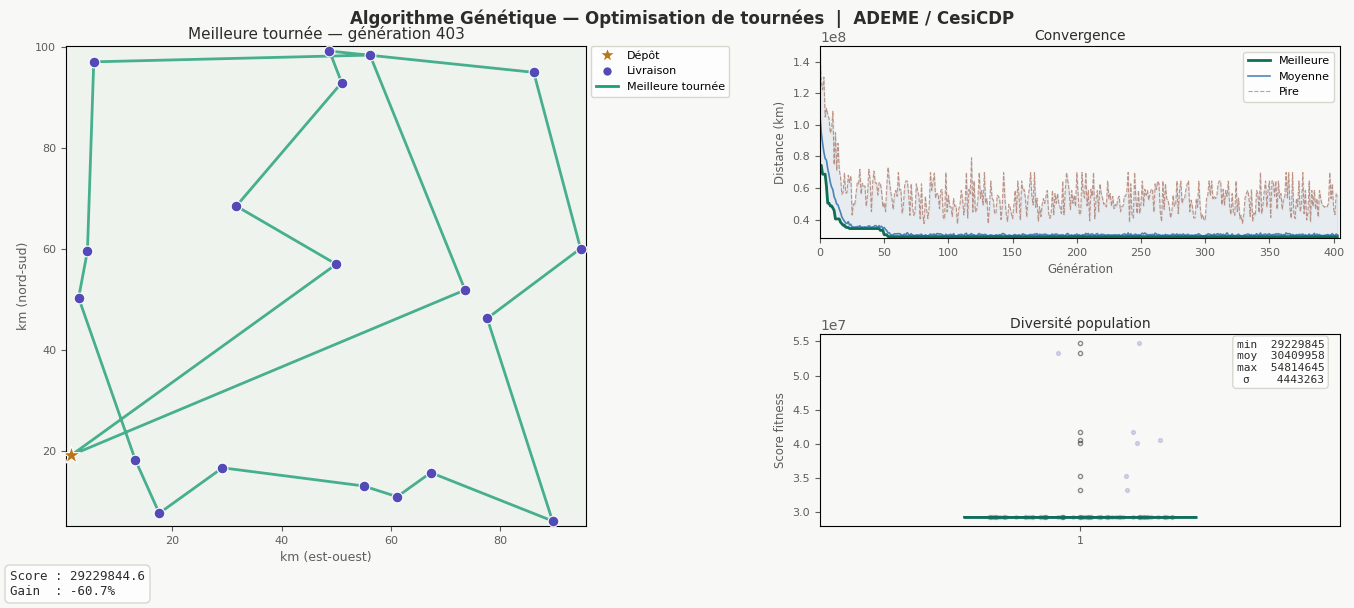


  Terminé en 2.58s  |  score initial 74391170 → 29229845  |  Gain : -60.7%


In [23]:
# ── Exemple 2 : TSPTW-D avec fenêtres temporelles et une perturbation ────────
import random as _rnd

villes_raw = charger_villes_depuis_split(chunk_size=20, source="tsp")
print(f"Villes chargées : {len(villes_raw)}")

# Ajout de fenêtres temporelles synthétiques sur chaque client
# (le dépôt a une journée complète de 0 à 480 min)
_rnd.seed(42)
villes_raw[0].a, villes_raw[0].b = 0, 480
for v in villes_raw[1:]:
    ouverture  = _rnd.randint(0, 300)
    fermeture  = ouverture + _rnd.randint(60, 180)
    v.a, v.b   = ouverture, fermeture
    v.service  = 10.0   # 10 minutes de service par client

# Perturbation : l'arc entre le client 1 et le client 3 est
# 3x plus lent entre t=80 et t=200 minutes
perturbations_exemple = [
    {'arc': (1, 3), 't_debut': 80, 't_fin': 200, 'alpha': 3.0},
    {'arc': (2, 5), 't_debut': 50, 't_fin': 150, 'alpha': 2.0},
]

lancer_visualisation(
    villes_raw,
    perturbations   = perturbations_exemple,
    taille_pop      = 80,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 350,
);


Villes chargées : 100
  Arrêt anticipé — génération 3025 (stagnation sur 350 gén.)


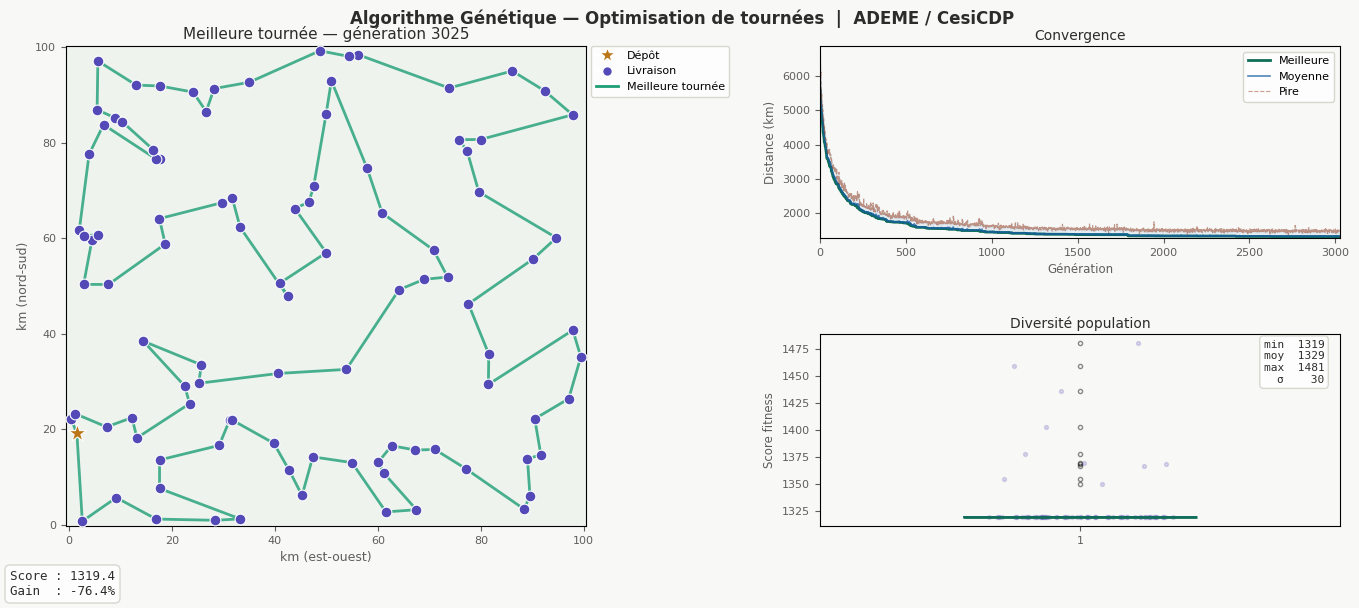


  Terminé en 56.54s  |  score initial 5601 → 1319  |  Gain : -76.4%


In [24]:
# ── Exemple 3 : grande instance, fenêtres larges + perturbation ──────────────
villes = charger_villes_depuis_split(chunk_size=100, source="tsp")
print(f"Villes chargées : {len(villes)}")

# Fenêtres larges (peu contraignantes)
villes[0].a, villes[0].b = 0, 9999
for v in villes[1:]:
    v.a, v.b  = 0, 9999
    v.service = 5.0

perturbations_large = [
    {'arc': (0, 1), 't_debut': 0, 't_fin': 500, 'alpha': 2.5},
]

lancer_visualisation(
    villes,
    perturbations   = perturbations_large,
    taille_pop      = 80,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 350,
);


Villes chargées : 200
  Arrêt anticipé — génération 5989 (stagnation sur 350 gén.)


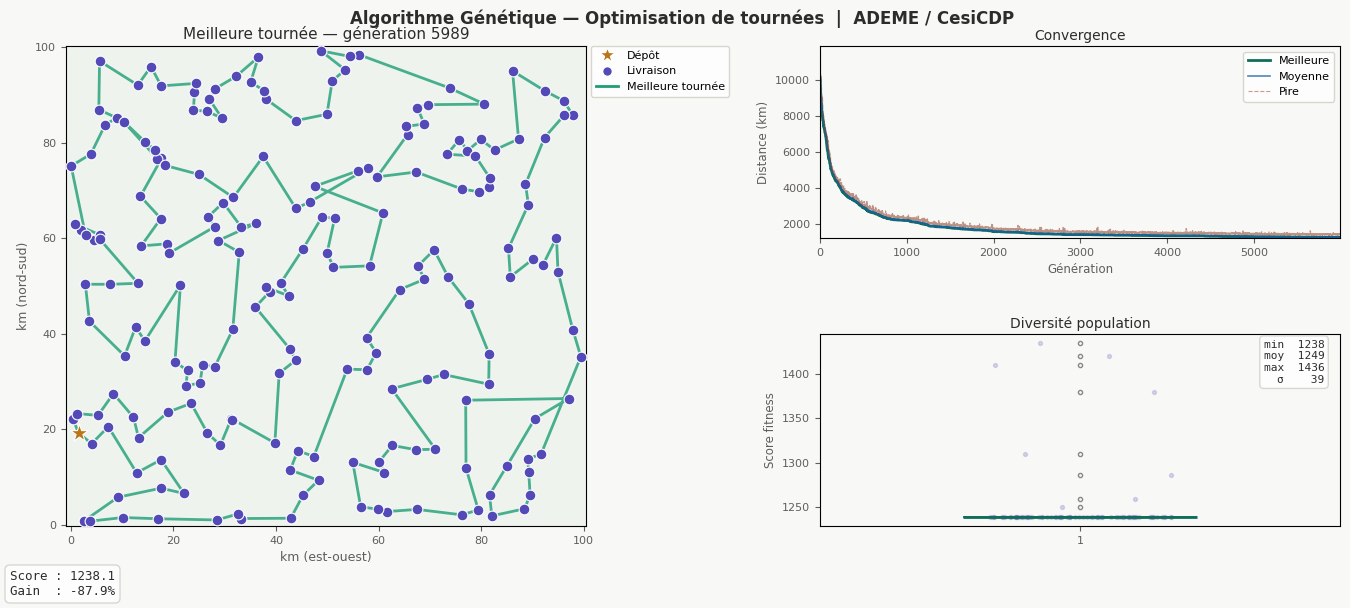


  Terminé en 137.70s  |  score initial 10203 → 1238  |  Gain : -87.9%


In [25]:
villes = charger_villes_depuis_split(chunk_size=200, source="tsp")
print(f"Villes chargées : {len(villes)}")
lancer_visualisation(
    villes,
    perturbations   = [],
    taille_pop      = 80,
    n_generations   = 20000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 350,
);


Villes chargées : 500
  Arrêt anticipé — génération 26670 (stagnation sur 500 gén.)


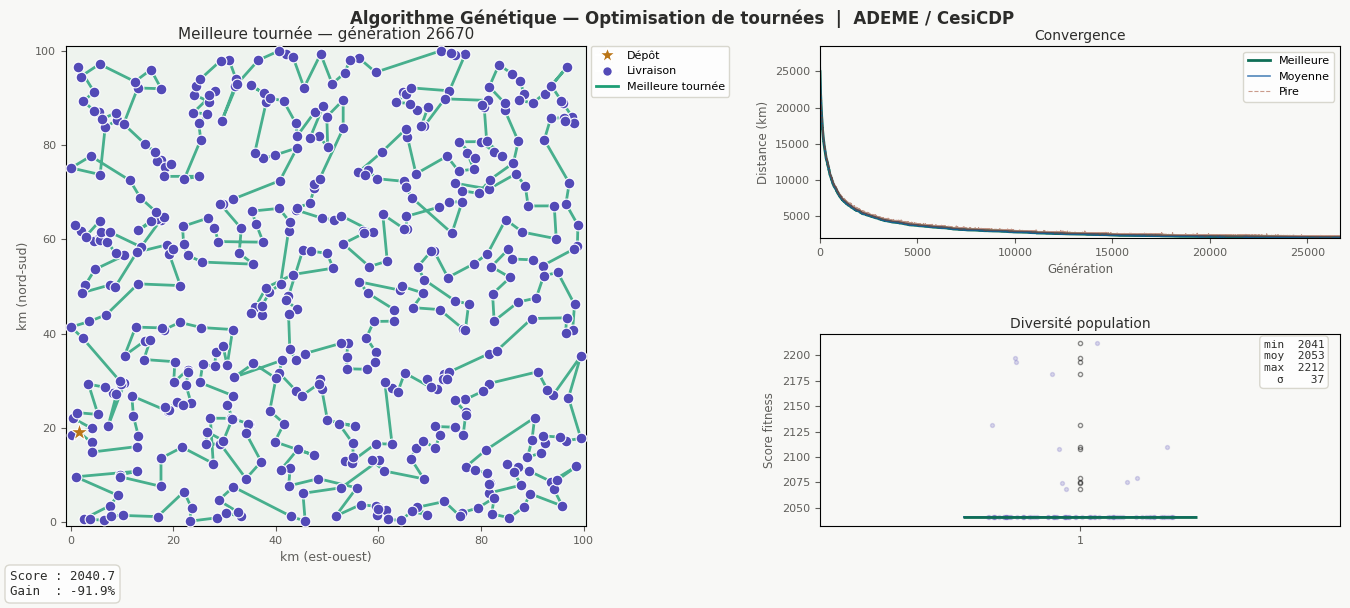


  Terminé en 1794.99s  |  score initial 25104 → 2041  |  Gain : -91.9%


In [26]:
villes = charger_villes_depuis_split(chunk_size=500, source="tsp")
print(f"Villes chargées : {len(villes)}")
lancer_visualisation(
    villes,
    perturbations   = [],
    taille_pop      = 80,
    n_generations   = 1000000,
    taux_croisement = 0.85,
    taux_mutation   = 0.12,
    taux_elitisme   = 0.10,
    patience        = 500,
);
